# Notebook 1: Exploratory Data Analysis (EDA)

## Dataset Selection: CIFAR-10

### Why CIFAR-10 is appropriate for convolutional layers:

1. **Image-based dataset**: CIFAR-10 contains 32x32 color images, making it ideal for CNNs
2. **Spatial structure**: Images have natural 2D spatial relationships that convolutions can exploit
3. **Translation invariance**: Objects can appear at different positions in images
4. **Local patterns**: Features like edges, textures, and shapes are localized
5. **Computational feasibility**: Small image size (32x32) allows for quick experimentation

### Dataset Properties:
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- **60,000 images total**: 50,000 training + 10,000 test
- **Image dimensions**: 32x32x3 (RGB)
- **Balanced classes**: 6,000 images per class

In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from src.utils.data_loader import get_cifar10_loaders, get_class_names
from src.utils.visualization import plot_sample_images, plot_class_distribution

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load the Dataset

In [2]:
# Load CIFAR-10 dataset (without normalization for visualization)
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root='../data/raw', train=True, 
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='../data/raw', train=False, 
                                 download=True, transform=transform)

class_names = get_class_names()

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

100%|██████████| 170M/170M [00:20<00:00, 8.38MB/s] 
/Users/dsbaenar/development/AREP/Taller03/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10


## 2. Dataset Structure

In [3]:
# Get a sample image
sample_image, sample_label = train_dataset[0]

print(f"Image shape: {sample_image.shape}")
print(f"Image dimensions: {sample_image.shape[1]}x{sample_image.shape[2]}")
print(f"Number of channels: {sample_image.shape[0]}")
print(f"Data type: {sample_image.dtype}")
print(f"Value range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
print(f"Label: {sample_label} ({class_names[sample_label]})")

Image shape: torch.Size([3, 32, 32])
Image dimensions: 32x32
Number of channels: 3
Data type: torch.float32
Value range: [0.000, 1.000]
Label: 6 (frog)


## 3. Class Distribution

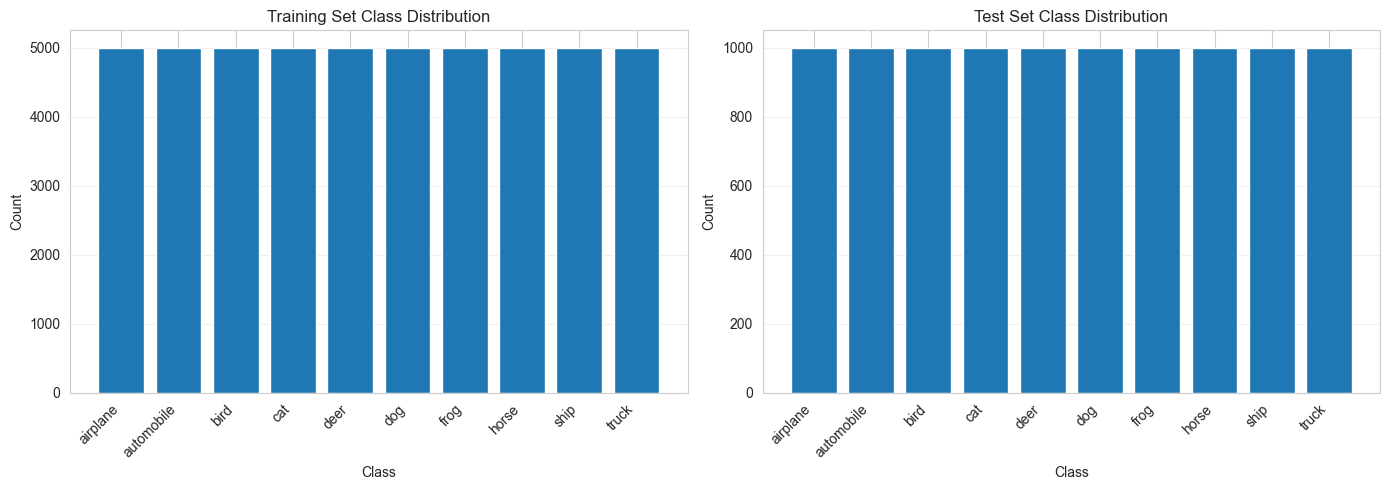

Dataset is perfectly balanced with equal samples per class


In [4]:
# Extract all labels
train_labels = np.array([label for _, label in train_dataset])
test_labels = np.array([label for _, label in test_dataset])

# Plot distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
unique_train, counts_train = np.unique(train_labels, return_counts=True)
ax1.bar(range(len(class_names)), counts_train)
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.set_title('Training Set Class Distribution')
ax1.set_xticks(range(len(class_names)))
ax1.set_xticklabels(class_names, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Test set distribution
unique_test, counts_test = np.unique(test_labels, return_counts=True)
ax2.bar(range(len(class_names)), counts_test)
ax2.set_xlabel('Class')
ax2.set_ylabel('Count')
ax2.set_title('Test Set Class Distribution')
ax2.set_xticks(range(len(class_names)))
ax2.set_xticklabels(class_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dataset is perfectly balanced with equal samples per class")

## 4. Sample Images per Class

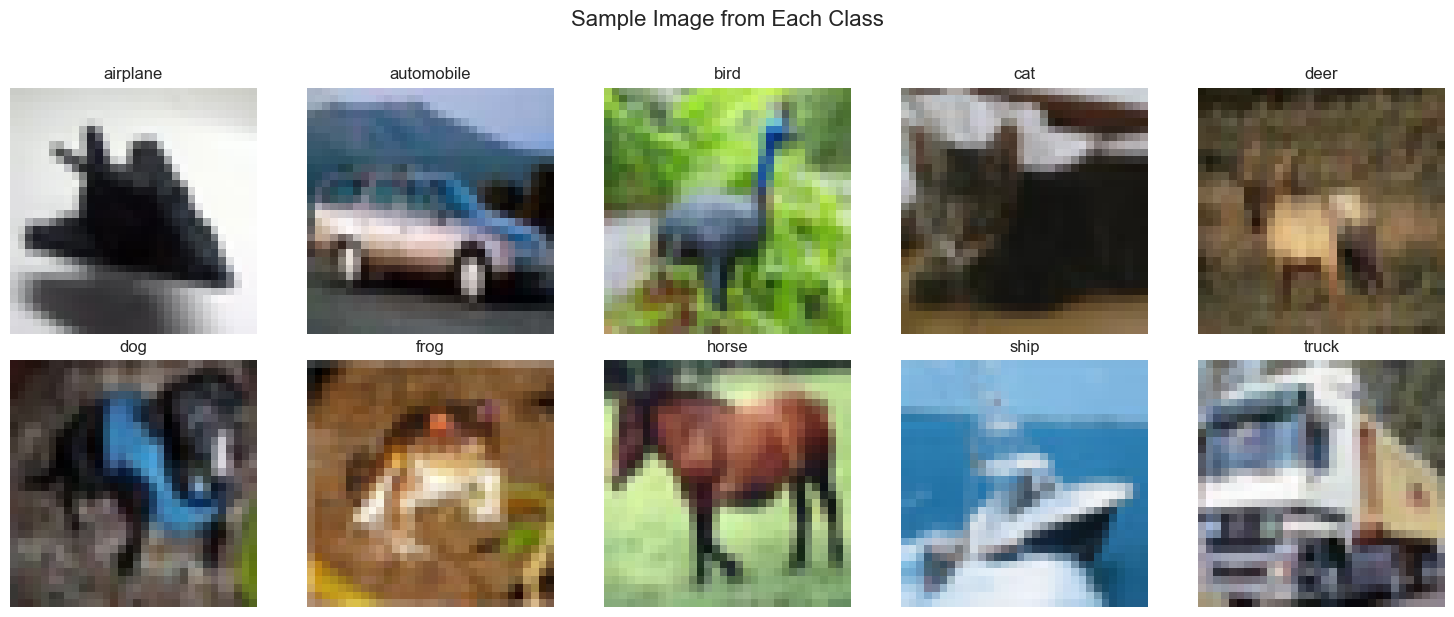

In [5]:
# Display one image from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for class_idx in range(10):
    # Find first image of this class
    for i, (img, label) in enumerate(train_dataset):
        if label == class_idx:
            img_np = img.permute(1, 2, 0).numpy()
            axes[class_idx].imshow(img_np)
            axes[class_idx].set_title(f'{class_names[class_idx]}')
            axes[class_idx].axis('off')
            break

plt.suptitle('Sample Image from Each Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/sample_images_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Pixel Statistics

In [6]:
# Calculate pixel statistics
all_pixels = []
for i in range(min(10000, len(train_dataset))):
    img, _ = train_dataset[i]
    all_pixels.append(img.numpy())

all_pixels = np.array(all_pixels)

# Per-channel statistics
mean_per_channel = all_pixels.mean(axis=(0, 2, 3))
std_per_channel = all_pixels.std(axis=(0, 2, 3))

print("Pixel Statistics (computed from 10,000 training samples):")
print(f"Mean per channel (R, G, B): {mean_per_channel}")
print(f"Std per channel (R, G, B): {std_per_channel}")
print("\nThese values will be used for normalization in training")

Pixel Statistics (computed from 10,000 training samples):
Mean per channel (R, G, B): [0.49345693 0.48337665 0.44717935]
Std per channel (R, G, B): [0.24762125 0.24458542 0.26261082]

These values will be used for normalization in training


## 6. Image Intensity Distribution

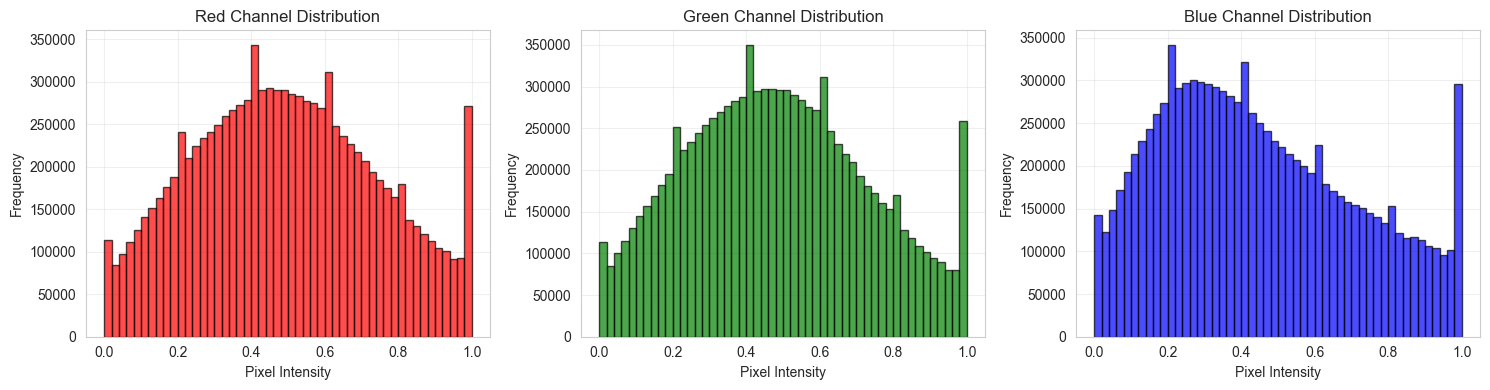

In [7]:
# Plot pixel intensity distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

for i, (ax, color, name) in enumerate(zip(axes, colors, channel_names)):
    channel_data = all_pixels[:, i, :, :].flatten()
    ax.hist(channel_data, bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} Channel Distribution')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/pixel_intensity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Multiple Samples from Single Class

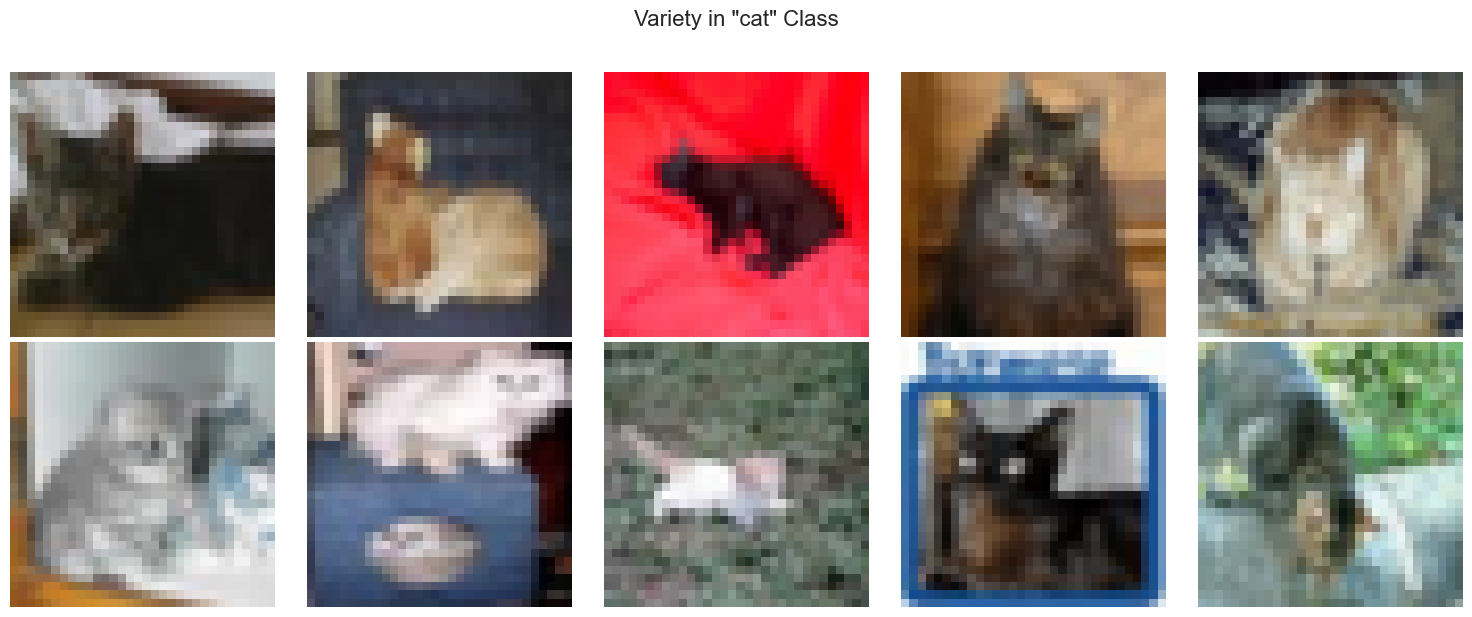

In [8]:
# Show variety within a single class (e.g., 'cat')
target_class = 3  # cat
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

cat_images = []
for img, label in train_dataset:
    if label == target_class:
        cat_images.append(img)
    if len(cat_images) == 10:
        break

for idx, img in enumerate(cat_images):
    img_np = img.permute(1, 2, 0).numpy()
    axes[idx].imshow(img_np)
    axes[idx].axis('off')

plt.suptitle(f'Variety in "{class_names[target_class]}" Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/class_variety.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Preprocessing Requirements

### Required Preprocessing Steps:

1. **Normalization**: 
   - Subtract mean and divide by std per channel
   - Mean: [0.4914, 0.4822, 0.4465]
   - Std: [0.2023, 0.1994, 0.2010]

2. **Data Augmentation** (training only):
   - Random horizontal flip
   - Random crop with padding

3. **Tensor Conversion**: Convert PIL images to PyTorch tensors

### Why these preprocessing steps?

- **Normalization** helps the neural network converge faster
- **Data augmentation** reduces overfitting and improves generalization
- **Standard format** ensures compatibility with PyTorch models

## Summary

### Key Findings:

1. **Dataset Size**: 50,000 training + 10,000 test images
2. **Image Dimensions**: 32×32×3 (RGB)
3. **Classes**: 10 balanced classes
4. **Pixel Range**: [0, 1] after ToTensor()
5. **Normalization**: Per-channel mean and std calculated

### Why CIFAR-10 is Ideal for CNNs:

- **Spatial Structure**: Images have 2D spatial relationships
- **Local Patterns**: Objects have local features (edges, textures)
- **Translation Invariance**: Objects appear at different positions
- **Small Size**: 32×32 allows fast experimentation
- **Sufficient Complexity**: 10 classes provide meaningful challenge

### Next Steps:

1. Implement baseline fully-connected model
2. Design and train CNN architecture
3. Compare performance and analyze results